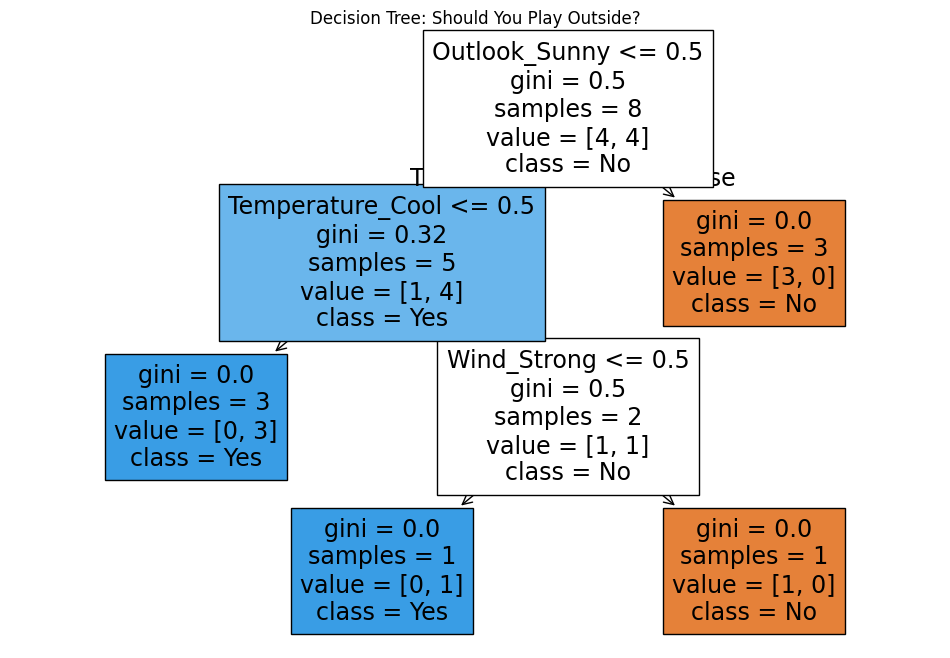


Prediction (Play?): No


In [2]:
# Decision Tree for "Play Outside" Prediction

import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# -------------------------------
# 1. Create Dataset
# -------------------------------
# Features: Weather conditions
data = {
    "Outlook": ["Sunny", "Sunny", "Overcast", "Rain", "Rain", "Rain", "Overcast", "Sunny"],
    "Temperature": ["Hot", "Hot", "Hot", "Mild", "Cool", "Cool", "Mild", "Cool"],
    "Humidity": ["High", "High", "High", "High", "Normal", "Normal", "Normal", "High"],
    "Wind": ["Weak", "Strong", "Weak", "Weak", "Weak", "Strong", "Strong", "Weak"],
    "Play": ["No", "No", "Yes", "Yes", "Yes", "No", "Yes", "No"]
}

df = pd.DataFrame(data)

# -------------------------------
# 2. Convert Categorical Data to Numbers
# -------------------------------
# Machine learning models require numerical input
df_encoded = pd.get_dummies(df.drop("Play", axis=1))
y = df["Play"]

# -------------------------------
# 3. Train Decision Tree Model
# -------------------------------
model = DecisionTreeClassifier()
model.fit(df_encoded, y)

# -------------------------------
# 4. Visualize Decision Tree
# -------------------------------
plt.figure(figsize=(12, 8))
plot_tree(
    model,
    feature_names=df_encoded.columns,
    class_names=["No", "Yes"],
    filled=True
)
plt.title("Decision Tree: Should You Play Outside?")
plt.show()

# -------------------------------
# 5. Predict Example
# -------------------------------
# Example: Sunny, Cool, High humidity, Weak wind
# Create sample input (same format as original data)
sample_raw = pd.DataFrame({
    "Outlook": ["Sunny"],
    "Temperature": ["Cool"],
    "Humidity": ["High"],
    "Wind": ["Weak"]
})

# Apply same encoding as training
sample_encoded = pd.get_dummies(sample_raw)

# Align columns with training data (VERY IMPORTANT)
sample_encoded = sample_encoded.reindex(columns=df_encoded.columns, fill_value=0)

# Predict
prediction = model.predict(sample_encoded)

print("\nPrediction (Play?):", prediction[0])